# MVP de Machine Learning & Analytics: Previsão de Churn de Cartão de Crédito (Parte 02)

- **Aluno:** Diogo Reis Beltrão Lessa
- **Curso:** Pós-Graduação em Ciência de Dados e Analytics, PUC-Rio
- **Parte 01 (EDA + pré-processamento):** https://github.com/diogorblessa/mvp-credit-card-churn-parte-01

Este notebook continua a parte 01, que cobriu a análise exploratória e o pré-processamento.
Aqui o foco é **modelagem, otimização de hiperparâmetros e avaliação**.

## Checklist do MVP

Use esta lista como guia. Cada pergunta é respondida na seção indicada.

1. **Definição do problema** → Seção 1
2. **Descrição dos dados** → Seção 3
3. **Preparação dos dados** → Seções 5 e 6
4. **Divisão dos dados** → Seção 5
5. **Modelagem** → Seções 7 e 8
6. **Otimização** → Seção 9
7. **Avaliação** → Seções 10 e 11
8. **Conclusão** → Seção 13

# 1. Definição do problema

## 1.1 Descrição do problema

Um banco percebeu que parte dos seus clientes cancela o cartão de crédito (o chamado churn). Esses cancelamentos são um problema de negócio, porque conquistar um cliente novo costuma custar mais do que manter um cliente atual. A ideia é identificar com antecedência quais clientes têm maior chance de cancelar, para que o banco possa agir antes, por exemplo oferecendo benefícios ou melhor atendimento.

Os dados descrevem o perfil e o comportamento de uso de `10.127` clientes. A quantidade exata de atributos e a taxa de cancelamento são apresentadas e confirmadas nas seções 3 e 4.

## 1.2 Objetivo do MVP

O objetivo é construir e comparar modelos de classificação que estimem a chance de um cliente cancelar o cartão (`Attrition_Flag`). A parte 01 deste trabalho cuidou de entender e preparar os dados (análise exploratória e pré-processamento). Aqui, na parte 02, o foco é a etapa de previsão: definir um modelo de referência simples (baseline), treinar modelos candidatos, ajustar seus hiperparâmetros e avaliar o desempenho em dados que o modelo não viu durante o treino.

## 1.3 Tipo de problema

Este é um problema de classificação binária supervisionada. A variável que queremos prever, `Attrition_Flag`, tem apenas dois valores possíveis: `Existing Customer` (cliente ativo) e `Attrited Customer` (cliente que cancelou). É supervisionado porque cada cliente já vem com a resposta correta (o rótulo), e o modelo aprende a partir desses exemplos. Faz sentido tratar com Machine Learning porque existem padrões de comportamento ligados ao cancelamento que um modelo consegue aprender a partir dos atributos.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Premissas**
- O conjunto de dados representa bem os clientes do banco.
- A categoria `Unknown`, presente em algumas colunas, indica informação não preenchida, e não uma categoria real.
- O comportamento passado do cliente ajuda a prever se ele vai cancelar.

**Hipóteses (levantadas na parte 01)**
- H1: clientes mais inativos tendem a cancelar mais.
- H2: clientes que usam pouco o limite do cartão tendem a cancelar mais.
- H3: clientes com menos produtos contratados no banco tendem a cancelar mais.
- H4: a faixa de renda influencia a chance de cancelamento.
- H5: a queda no número de transações ao longo do tempo está ligada ao cancelamento.

**Critério de sucesso**
Como as classes são desbalanceadas (a maioria dos clientes não cancela), a acurácia sozinha engana: um modelo que sempre responde "não cancela" acertaria a maior parte dos casos, mas não serviria para nada na prática. Por isso, o sucesso será medido pela capacidade de identificar quem cancela, dando atenção ao `recall` e ao `F1` da classe de churn, além do `ROC-AUC`. A meta mínima é superar o modelo de referência (baseline).

# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
# === Setup do ambiente e reprodutibilidade ===
# Bibliotecas em relação ao template (este projeto segue só o caminho de classificação):
#   + xgboost (XGBClassifier): modelo candidato extra, além dos do template
#   mantidos: numpy, pandas, matplotlib, seaborn, scikit-learn
#   removidos os imports de regressão/clusterização do template (Ridge, KMeans,
#   DummyRegressor, silhouette_score), que não se aplicam a este problema.
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import xgboost
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay,
    confusion_matrix as matriz_confusao,
)
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Semente única, reutilizada nos splits, na validação cruzada e nos modelos,
# para que o notebook produza sempre os mesmos resultados.
SEED = 7
np.random.seed(SEED)
random.seed(SEED)

print("Bibliotecas carregadas com sucesso!")
print("Versões das bibliotecas:")
print("  Python      :", sys.version.split()[0])
print("  numpy       :", np.__version__)
print("  pandas      :", pd.__version__)
print("  scikit-learn:", sklearn.__version__)
print("  seaborn     :", sns.__version__)
print("  xgboost     :", xgboost.__version__)

Bibliotecas carregadas com sucesso!
Versões das bibliotecas:
  Python      : 3.14.2
  numpy       : 2.4.2
  pandas      : 3.0.0
  scikit-learn: 1.8.0
  seaborn     : 0.13.2
  xgboost     : 3.2.0


## 2.1 Dependências adicionais

O notebook foi pensado para rodar no Google Colab, que já traz `numpy`, `pandas`, `matplotlib`, `seaborn` e `scikit-learn`. A única dependência fora desse padrão é o `xgboost`, usado como modelo candidato extra na Seção 7.

A célula abaixo garante o `xgboost` no ambiente. No Colab ele normalmente já vem instalado, então a instalação é rápida; para reproduzir localmente, use o `requirements.txt` do repositório.

In [2]:
# Garante o xgboost no ambiente de execução.
# No Colab ele costuma já vir instalado; o pip é idempotente, então rodar de novo não atrapalha.
%pip install -q xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\User\.pyenv\pyenv-win\versions\3.14.2\python.exe -m pip install --upgrade pip


## 2.2 Funções auxiliares

Para não repetir código nas Seções 8, 10 e 11, definimos funções que avaliam um modelo e desenham a matriz de confusão. Como o problema é desbalanceado, as métricas de `precision`, `recall` e `F1` são sempre calculadas para a classe de churn (a classe que de fato interessa identificar).

In [3]:
# Convenção de rótulos (definida na Seção 5):
#   churn = 'Attrited Customer' = 1  (classe positiva, que queremos identificar)
#   ativo = 'Existing Customer' = 0
# As métricas abaixo usam pos_label=1, ou seja, descrevem o desempenho na classe de churn.


def avaliar_classificacao(nome, y_true, y_pred, y_proba=None):
    """Calcula as métricas de classificação para um modelo.

    Parâmetros:
        nome    : nome do modelo (vira o rótulo da linha na tabela de resultados).
        y_true  : rótulos verdadeiros (0/1).
        y_pred  : rótulos previstos (0/1).
        y_proba : probabilidade prevista da classe de churn (1), usada no ROC-AUC.

    Retorna uma pandas.Series com accuracy, precision, recall, f1 e roc_auc.
    """
    metricas = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }
    return pd.Series(metricas, name=nome)


def tabela_resultados(series_modelos):
    """Junta as Series de vários modelos numa tabela, ordenada por f1 (maior primeiro)."""
    return pd.DataFrame(series_modelos).sort_values("f1", ascending=False)


def plotar_matriz_confusao(y_true, y_pred, titulo="Matriz de confusão"):
    """Desenha a matriz de confusão e imprime suas contagens em texto."""
    display = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Ativo (0)", "Churn (1)"],
        cmap="viridis",
    )
    # Remove a grade do tema whitegrid, que se sobrepõe às células e atrapalha a leitura.
    display.ax_.grid(False)
    plt.title(titulo)
    plt.show()

    # Versão em texto da matriz, para ler as contagens exatas fora da imagem.
    # As linhas são a classe real e as colunas a classe prevista, na mesma ordem do gráfico.
    tabela_matriz = pd.DataFrame(
        matriz_confusao(y_true, y_pred),
        index=["Real: Ativo (0)", "Real: Churn (1)"],
        columns=["Previsto: Ativo (0)", "Previsto: Churn (1)"],
    )
    print(tabela_matriz)

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados
Credit Card Customers (BankChurners), reaproveitado da parte 01 e carregado por URL pública
raw, sem upload, login ou token.

In [4]:
# Carga direta por URL raw pública do repositório da parte 01 (sem upload, login ou token).
url = "https://raw.githubusercontent.com/diogorblessa/mvp-credit-card-churn-parte-01/main/data/BankChurners.csv"
df = pd.read_csv(url)

print("Dataset carregado:", df.shape[0], "linhas e", df.shape[1], "colunas")
df.head()

Dataset carregado: 10127 linhas e 23 colunas


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


## 3.2 Visão geral do dataset

A célula abaixo confirma a estrutura da base:

- `10.127` registros e `23` atributos.
- Nenhum valor ausente como `NaN` e nenhuma linha duplicada.
- A carga foi feita diretamente de uma `URL` raw pública com `pandas.read_csv`, sem upload manual nem login.

Um ponto pede atenção: embora não existam `NaN`, três colunas categóricas usam a categoria `Unknown` como proxy de informação não preenchida (`Education_Level`, `Income_Category` e `Marital_Status`). Por isso a contagem de ausentes dá zero, mas há, sim, informação faltante "disfarçada" de categoria. O detalhamento fica no dicionário (Seção 3.3) e o tratamento na preparação dos dados (Seções 5 e 6).

In [5]:
# Dimensões, tipos de dados, ausentes e duplicatas.
print("Formato (linhas, colunas):", df.shape)

print("\nTipos de dados por coluna:")
display(df.dtypes.to_frame("tipo"))

print("\nTotal de valores ausentes (NaN):", int(df.isna().sum().sum()))
print("Linhas duplicadas:", int(df.duplicated().sum()))

# Os ausentes reais aparecem como a categoria 'Unknown', não como NaN.
unknown = {c: int((df[c] == "Unknown").sum())
           for c in df.select_dtypes(include="object").columns}
unknown = {c: n for c, n in unknown.items() if n > 0}
print("\n'Unknown' por coluna:", unknown)


Formato (linhas, colunas): (10127, 23)

Tipos de dados por coluna:


,tipo
CLIENTNUM,int64
Attrition_Flag,str
Customer_Age,int64
Gender,str
Dependent_count,int64
Education_Level,str
Marital_Status,str
Income_Category,str
Card_Category,str
Months_on_book,int64



Total de valores ausentes (NaN): 0
Linhas duplicadas: 0

'Unknown' por coluna: {'Education_Level': 1519, 'Marital_Status': 749, 'Income_Category': 1112}


## 3.3 Dicionário de dados

A variável-alvo é `Attrition_Flag`: ela indica se o cliente continua ativo (`Existing Customer`) ou se cancelou o cartão (`Attrited Customer`). É essa coluna que os modelos vão tentar prever. O dicionário abaixo reaproveita as descrições da parte 01 e indica quais colunas entram no modelo.

| Coluna | Tipo | Descrição | Usada no modelo? |
|---|---|---|---|
| `Attrition_Flag` | categórica (alvo) | Status do cliente: `Existing Customer` ou `Attrited Customer` | Alvo |
| `CLIENTNUM` | numérica (ID) | Identificador único do cliente | Não (é só um ID, removida na Seção 5) |
| `Customer_Age` | numérica | Idade do cliente, em anos | Sim |
| `Gender` | categórica | Gênero: `M` ou `F` | Sim |
| `Dependent_count` | numérica | Número de dependentes (`0` a `5`) | Sim |
| `Education_Level` | categórica | Escolaridade: `Uneducated`, `High School`, `College`, `Graduate`, `Post-Graduate`, `Doctorate`, `Unknown` | Sim |
| `Marital_Status` | categórica | Estado civil: `Married`, `Single`, `Divorced`, `Unknown` | Sim |
| `Income_Category` | categórica | Faixa de renda: `Less than $40K`, `$40K - $60K`, `$60K - $80K`, `$80K - $120K`, `$120K +`, `Unknown` | Sim |
| `Card_Category` | categórica | Tipo de cartão: `Blue`, `Silver`, `Gold`, `Platinum` | Sim |
| `Months_on_book` | numérica | Tempo como cliente do banco, em meses | Sim |
| `Total_Relationship_Count` | numérica | Total de produtos contratados com o banco (`1` a `6`) | Sim |
| `Months_Inactive_12_mon` | numérica | Meses inativos nos últimos 12 meses | Sim |
| `Contacts_Count_12_mon` | numérica | Número de contatos com o banco nos últimos 12 meses | Sim |
| `Credit_Limit` | numérica | Limite de crédito do cartão | Sim |
| `Total_Revolving_Bal` | numérica | Saldo rotativo total (quanto o cliente deve no cartão) | Sim |
| `Avg_Open_To_Buy` | numérica | Limite disponível médio (`Credit_Limit` menos `Total_Revolving_Bal`) | Sim |
| `Total_Amt_Chng_Q4_Q1` | numérica | Variação do valor transacionado entre Q4 e Q1 | Sim |
| `Total_Trans_Amt` | numérica | Valor total transacionado no período | Sim |
| `Total_Trans_Ct` | numérica | Contagem total de transações no período | Sim |
| `Total_Ct_Chng_Q4_Q1` | numérica | Variação da contagem de transações entre Q4 e Q1 | Sim |
| `Avg_Utilization_Ratio` | numérica | Taxa média de utilização do crédito (`0.0` a `1.0`) | Sim |
| `Naive_Bayes_Classifier_..._1` | numérica | Score pré-calculado por um classificador Naive Bayes externo (classe 1) | Não (removida na Seção 5) |
| `Naive_Bayes_Classifier_..._2` | numérica | Score pré-calculado por um classificador Naive Bayes externo (classe 2) | Não (removida na Seção 5) |

**Limitações conhecidas**
- As colunas `Education_Level`, `Income_Category` e `Marital_Status` trazem a categoria `Unknown` no lugar de valores faltantes. Tratar isso como uma categoria comum pode introduzir ruído; a decisão de tratamento é feita nas Seções 5 e 6.
- As duas colunas `Naive_Bayes_Classifier_...` são scores já calculados por outro modelo a partir do próprio alvo. Mantê-las causaria vazamento de informação, então são descartadas antes da modelagem (Seção 5). O `CLIENTNUM` é apenas um identificador e também sai.
- Alguns atributos numéricos são fortemente correlacionados entre si (por exemplo `Credit_Limit` e `Avg_Open_To_Buy`), conforme apontado na parte 01; essa multicolinearidade é retomada na Seção 5.
- As classes são desbalanceadas (a maioria dos clientes não cancela); isso é quantificado e tratado a partir da Seção 4.

# 4. Análise exploratória dos dados

A EDA completa foi feita na **parte 01** (estatísticas, histogramas, boxplots por grupo,
bivariadas, correlação/multicolinearidade, tratamento de `Unknown`). Aqui fazemos apenas uma
**verificação mínima** para tornar este notebook autossuficiente antes da modelagem.

In [6]:
# Verificação mínima da variável-alvo antes da modelagem.
# A EDA completa está na parte 01; aqui só confirmamos o que orienta as decisões.

# Distribuição da variável-alvo: confirma o desbalanceamento (cerca de 16% de churn).
contagem = df["Attrition_Flag"].value_counts()
percentual = (df["Attrition_Flag"].value_counts(normalize=True) * 100).round(2)
print("Distribuição da variável-alvo (Attrition_Flag):")
display(pd.concat([contagem.rename("contagem"),
                   percentual.rename("percentual_%")], axis=1))

# Alvo binário temporário, só para medir associação (a definição oficial fica na Seção 5).
y_churn = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

# Força de associação (linear) das features numéricas com o churn.
# Removem-se o ID e os scores Naive_Bayes, que não são preditores válidos (Seção 3.3).
num = df.select_dtypes(include=np.number).drop(columns=["CLIENTNUM"])
num = num[[c for c in num.columns if not c.startswith("Naive_Bayes_Classifier")]]
corr_alvo = num.corrwith(y_churn).abs().sort_values(ascending=False)
print("\nCorrelação absoluta de cada feature numérica com o churn:")
display(corr_alvo.round(3).to_frame("correlação"))

# Confirma o par multicolinear apontado na parte 01 (decide o descarte na Seção 5).
r_par = df["Credit_Limit"].corr(df["Avg_Open_To_Buy"])
print(f"\nCorrelação Credit_Limit x Avg_Open_To_Buy: {r_par:.3f}")

Distribuição da variável-alvo (Attrition_Flag):


,contagem,percentual_%
Attrition_Flag,,
Existing Customer,8500,83.93
Attrited Customer,1627,16.07



Correlação absoluta de cada feature numérica com o churn:


,correlação
Total_Trans_Ct,0.371
Total_Ct_Chng_Q4_Q1,0.290
Total_Revolving_Bal,0.263
Contacts_Count_12_mon,0.204
Avg_Utilization_Ratio,0.178
Total_Trans_Amt,0.169
Months_Inactive_12_mon,0.152
Total_Relationship_Count,0.150
Total_Amt_Chng_Q4_Q1,0.131
Credit_Limit,0.024



Correlação Credit_Limit x Avg_Open_To_Buy: 0.996


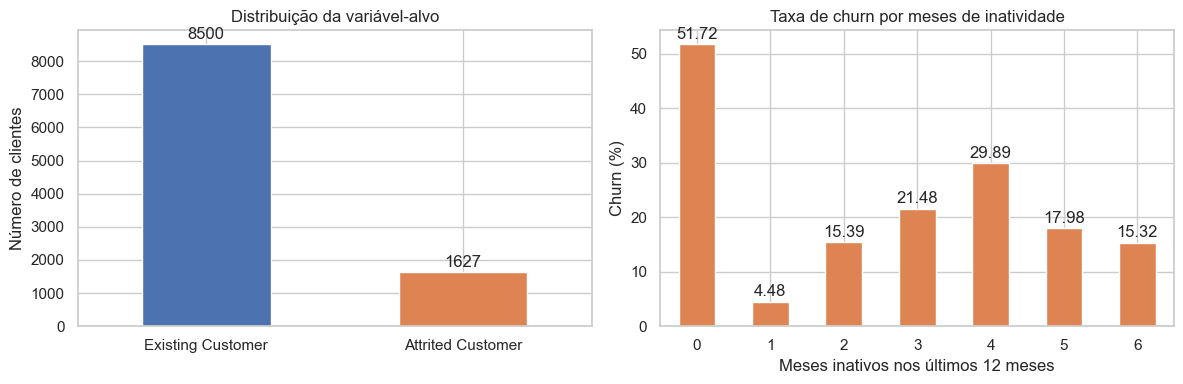

In [7]:
# Dois gráficos-chave que justificam decisões de modelagem.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Desbalanceamento da variável-alvo: a maioria dos clientes permanece ativa.
contagem.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Distribuição da variável-alvo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Número de clientes")
axes[0].tick_params(axis="x", rotation=0)
axes[0].bar_label(axes[0].containers[0], fmt="%d", padding=2)

# 2) Taxa de churn por meses de inatividade: sinal comportamental não linear.
taxa_inatividade = df.groupby("Months_Inactive_12_mon")["Attrition_Flag"].apply(
    lambda s: (s == "Attrited Customer").mean() * 100
)
taxa_inatividade.plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Taxa de churn por meses de inatividade")
axes[1].set_xlabel("Meses inativos nos últimos 12 meses")
axes[1].set_ylabel("Churn (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f", padding=2)

plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

A verificação acima confirma os pontos da parte 01 que mais influenciam a modelagem:

- **Desbalanceamento.** O churn representa `16,07%` dos clientes (`1.627` de `10.127`), contra `83,93%` de clientes ativos, cerca de `5:1`. Isso justifica usar `f1` e `recall` da classe de churn (e não a acurácia) como métricas principais e estratificar a divisão treino/teste.

- **Preditores mais fortes (lineares).** Pela correlação absoluta com o alvo, os sinais mais fortes são `Total_Trans_Ct` (`0,371`) e `Total_Ct_Chng_Q4_Q1` (`0,290`), seguidos de `Total_Revolving_Bal` (`0,263`) e `Contacts_Count_12_mon` (`0,204`). Quem cancela tende a transacionar menos e a reduzir o ritmo de uso entre os trimestres.

- **Sinais não lineares.** A correlação linear subestima variáveis de efeito não monotônico. `Months_Inactive_12_mon` fica só na 7ª posição (`0,152`), mas o gráfico de churn por inatividade mostra um salto de `4,48%` (1 mês) para `29,89%` (4 meses). O grupo de `0` meses tem apenas `29` clientes, então sua taxa alta (`51,72%`) é pouco confiável. Isso indica que modelos de árvore podem capturar esses padrões melhor que um modelo linear.

- **Multicolinearidade.** `Avg_Open_To_Buy` é quase redundante com `Credit_Limit` (`r = 0,996`), o que reforça descartar uma das duas na preparação dos dados (Seção 5).

- **Ausentes disfarçados.** As categorias `Unknown` em `Education_Level`, `Income_Category` e `Marital_Status` seguem tratadas como categoria informativa (parte 01; detalhe na Seção 6).

Esses achados orientam as próximas seções: remover colunas não preditoras e o par multicolinear (Seção 5), padronizar e codificar (Seção 6) e priorizar modelos de árvore entre os candidatos (Seção 7).

# 5. Preparação dos dados e divisão treino/teste

In [8]:
# Preparação dos dados: define o alvo binário, remove colunas não preditoras e separa X e y.

# Alvo binário seguindo a convenção do notebook (Seção 2.2):
#   churn = 'Attrited Customer' = 1 (classe positiva); 
#   ativo = 'Existing Customer' = 0.
y = (df["Attrition_Flag"] == "Attrited Customer").astype(int)

# Colunas removidas antes da modelagem (justificativa na Seção 3.3):
#   CLIENTNUM: apenas um identificador, sem poder preditivo.
#   Naive_Bayes_Classifier_*: scores calculados a partir do próprio alvo, causam vazamento.
colunas_nao_preditoras = ["CLIENTNUM"] + [
    c for c in df.columns if c.startswith("Naive_Bayes_Classifier")
]

# Pares multicolineares apontados na parte 01: confirmamos a correlação antes de decidir.
pares_multicolineares = [
    ("Credit_Limit", "Avg_Open_To_Buy"),
    ("Total_Trans_Amt", "Total_Trans_Ct"),
    ("Customer_Age", "Months_on_book"),
]
print("Correlação dentro de cada par multicolinear:")
for a, b in pares_multicolineares:
    print(f"  {a} x {b}: {df[a].corr(df[b]):.3f}")

# Decisão: remover apenas Avg_Open_To_Buy, redundante com Credit_Limit (r ~ 0,996) e com correlação praticamente nula com o alvo (Seção 4). Os outros dois pares (r ~ 0,81 e r ~ 0,79) são apenas moderados e carregam informação distinta, então são mantidos; os modelos de árvore (Seção 7) lidam bem com essa correlação residual.
colunas_redundantes = ["Avg_Open_To_Buy"]

colunas_removidas = colunas_nao_preditoras + colunas_redundantes + ["Attrition_Flag"]
X = df.drop(columns=colunas_removidas)

print("\nColunas removidas das features:", colunas_removidas)
print("Número de features restantes:", X.shape[1])

# Divisão treino/teste estratificada pelo alvo, com a mesma semente do restante do notebook.
# A estratificação preserva a proporção de churn (cerca de 16%) nos dois conjuntos, e o conjunto de teste fica reservado só para a avaliação final (Seção 10).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\nTreino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção de churn no treino: {:.2%} | no teste: {:.2%}".format(y_train.mean(), y_test.mean()))

Correlação dentro de cada par multicolinear:
  Credit_Limit x Avg_Open_To_Buy: 0.996
  Total_Trans_Amt x Total_Trans_Ct: 0.807
  Customer_Age x Months_on_book: 0.789

Colunas removidas das features: ['CLIENTNUM', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'Avg_Open_To_Buy', 'Attrition_Flag']
Número de features restantes: 18

Treino: (8101, 18) | Teste: (2026, 18)
Proporção de churn no treino: 16.07% | no teste: 16.04%


## 5.1 Justificativa da divisão

Usamos um holdout simples: `80%` dos dados para treino e `20%` para teste (`train_test_split`). Com `10.127` registros, `20%` equivalem a cerca de `2.026` clientes no teste, o suficiente para uma estimativa estável das métricas sem tirar dados demais do treino. A validação cruzada estratificada entra só mais adiante, na otimização (Seção 9), e sempre apenas sobre o treino.

A divisão é estratificada pelo alvo (`stratify=y`). Como o churn representa só `16,07%` dos clientes, uma divisão puramente aleatória poderia, por acaso, deixar proporções diferentes de churn no treino e no teste. A estratificação mantém os mesmos `~16%` de churn nos dois conjuntos, o que torna a avaliação mais justa e estável, ainda mais por se tratar de um problema desbalanceado.

**Como a divisão evita vazamento de dados:**
- As colunas `Naive_Bayes_Classifier_*` foram removidas antes do split, porque são scores calculados a partir do próprio alvo e dariam ao modelo uma informação que ele não teria na prática.
- Nesta etapa só removemos colunas e definimos o alvo; nenhuma estatística aprendida dos dados (médias, escalas, codificações) é aplicada aqui. Esses ajustes ficam no `Pipeline` da Seção 6, treinado apenas com `X_train` e depois aplicado em `X_test`, de modo que o conjunto de teste permanece intocado até a avaliação final (Seção 10).
- O `random_state=SEED` garante que a mesma divisão se repita a cada execução, mantendo o resultado reprodutível.

As categorias `Unknown` (em `Education_Level`, `Income_Category` e `Marital_Status`) são mantidas como categoria informativa, decisão herdada da parte 01; a forma de codificá-las é tratada no pipeline da Seção 6.

# 6. Pré-processamento e pipeline

In [9]:
# Define como cada tipo de coluna é tratado antes de chegar ao modelo.
# Aqui apenas DEFINIMOS as transformações; o ajuste (fit) acontece dentro dos pipelines de modelo (Seções 7 e 8), sempre sobre o treino, o que evita vazamento para o teste.

# Separa as features por tipo, a partir do conjunto de treino.
colunas_numericas = X_train.select_dtypes(include=np.number).columns.tolist()
colunas_categoricas = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Numéricas: padronização para média 0 e desvio 1. As escalas são muito diferentes entre si (por exemplo, Total_Trans_Amt na casa dos milhares e Avg_Utilization_Ratio entre 0 e 1), o que atrapalha modelos sensíveis a escala como LogisticRegression e KNN (Seção 7). Os modelos de árvore não dependem de escala, mas a padronização não os prejudica, então serve para todos.
# Categóricas: codificação one-hot. A categoria 'Unknown' (em Education_Level, Income_Category e Marital_Status) vira uma coluna indicadora própria, mantendo-a como informação (Seção 5).
# handle_unknown='ignore' evita erro caso alguma categoria apareça apenas no teste.
# Não usamos imputação: a Seção 3.2 confirmou zero valores ausentes (NaN) nesta base.
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
    ],
    remainder="drop",
)

print("Colunas numéricas:", len(colunas_numericas))
print(colunas_numericas)
print("\nColunas categóricas:", len(colunas_categoricas))
print(colunas_categoricas)

Colunas numéricas: 13
['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Colunas categóricas: 5
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


## 6.1 Decisões de pré-processamento

O pré-processamento foi definido como um único `ColumnTransformer`, que aplica um tratamento diferente para cada tipo de coluna.

**Numéricas (`13` colunas): padronização com `StandardScaler`.**
As escalas variam muito entre si (por exemplo, `Total_Trans_Amt` chega à casa dos milhares, enquanto `Avg_Utilization_Ratio` fica entre `0` e `1`). Modelos sensíveis a escala e a distância, como a `LogisticRegression` e o `KNN` (Seção 7), são prejudicados por isso, então padronizamos para média `0` e desvio `1`. Os modelos de árvore não dependem de escala, mas a padronização não os atrapalha, então uma única transformação atende a todos os candidatos.

**Categóricas (`5` colunas): codificação one-hot com `OneHotEncoder`.**
Cada categoria vira uma coluna indicadora (`0` ou `1`). Optamos por one-hot, e não por codificação ordinal, mesmo nas colunas com ordem natural (`Card_Category` e `Income_Category`), por dois motivos: a categoria `Unknown` não tem posição definida em uma escala ordenada, e modelos lineares e de distância interpretariam os códigos inteiros como quantidades reais, criando uma ordem artificial. O parâmetro `handle_unknown="ignore"` evita erro caso alguma categoria apareça apenas no conjunto de teste.

**Tratamento de `Unknown`.**
Seguindo a decisão da parte 01 e da Seção 5, `Unknown` (presente em `Education_Level`, `Income_Category` e `Marital_Status`) é mantido como categoria informativa, e não removido. Com o one-hot, ele apenas vira mais uma coluna indicadora, o que preserva a informação "dado não preenchido" sem inventar um valor.

**Por que não imputamos valores ausentes.**
A Seção 3.2 confirmou `0` valores `NaN` na base. Como não há ausentes reais (a falta de informação aparece como a categoria `Unknown`, já tratada acima), uma etapa de imputação não teria efeito, então foi deixada de fora para manter o pipeline enxuto.

**Por que o pipeline é ajustado só no treino.**
O `ColumnTransformer` aprende parâmetros a partir dos dados: a média e o desvio de cada coluna numérica e o conjunto de categorias de cada coluna categórica. Se esse aprendizado usasse o conjunto de teste, informações do teste vazariam para o treino e as métricas finais (Seção 10) ficariam otimistas demais. Por isso o `preprocessador` é encaixado nos pipelines de modelo (Seção 7) e ajustado apenas com `X_train`; o `X_test` só passa pela transformação já aprendida, na avaliação final.

# 7. Baseline e modelos candidatos

In [10]:
# Define o baseline e os modelos candidatos. Esta seção apenas DEFINE os modelos;
# o treinamento e a avaliação ficam na Seção 8. Cada modelo é embrulhado num Pipeline
# com o pré-processador da Seção 6, garantindo que o ajuste (fit) aconteça só no treino.

# Baseline: prevê sempre a classe majoritária (cliente ativo). Serve de referência mínima:
# se um candidato não superar isso, ele não aprendeu nada útil sobre o churn.
baseline = Pipeline(steps=[
    ("preprocess", preprocessador),
    ("model", DummyClassifier(strategy="most_frequent")),
])

# Peso para o desbalanceamento no XGBoost: razão entre clientes ativos (0) e churn (1) no treino.
# O XGBoost não tem class_weight; ele usa scale_pos_weight para dar mais peso à classe de churn.
peso_churn = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (ativos/churn no treino): {peso_churn:.2f}")

# Modelos candidatos, todos com a mesma semente (SEED) para reprodutibilidade.
# Tratamento do desbalanceamento por modelo:
#   class_weight='balanced' em LogisticRegression, RandomForest e HistGradientBoosting;
#   scale_pos_weight no XGBoost; KNeighbors não oferece reponderação nativa (ver Seção 7.1).
# Usamos os parâmetros padrão (mais max_iter na regressão logística, para garantir a
# convergência); o ajuste de hiperparâmetros fica para a Seção 9.
modelos_candidatos = {
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocessador),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ]),
    "KNN": Pipeline(steps=[
        ("preprocess", preprocessador),
        ("model", KNeighborsClassifier()),
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocessador),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=SEED)),
    ]),
    "HistGradientBoosting": Pipeline(steps=[
        ("preprocess", preprocessador),
        ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)),
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocess", preprocessador),
        ("model", XGBClassifier(scale_pos_weight=peso_churn, eval_metric="logloss", random_state=SEED)),
    ]),
}

# Os prints leem os próprios objetos definidos acima, em vez de repetir os nomes como texto fixo,
# para que o output reflita sempre o que o código de fato criou.
modelo_baseline = baseline.named_steps["model"]
print(f"\nBaseline definido: {type(modelo_baseline).__name__} (strategy='{modelo_baseline.strategy}').")
print("Modelos candidatos definidos:", list(modelos_candidatos.keys()))

scale_pos_weight (ativos/churn no treino): 5.22

Baseline definido: DummyClassifier (strategy='most_frequent').
Modelos candidatos definidos: ['LogisticRegression', 'KNN', 'RandomForest', 'HistGradientBoosting', 'XGBoost']


## 7.1 Justificativa dos modelos

Esta seção apenas define os modelos. A comparação de desempenho aparece depois do treino (Seções 8 e 11); aqui justificamos por que cada escolha faz sentido antes de rodar qualquer modelo.

**Baseline: `DummyClassifier` com `most_frequent`.**
Como o churn é só `16,07%` dos clientes (Seção 4.1), um modelo que sempre responde "cliente ativo" já acerta a maioria dos casos sem aprender nada. Esse é justamente o baseline: ele estabelece o piso que os candidatos precisam superar. Se um modelo não ganhar do baseline nas métricas da classe de churn (`recall` e `F1`), ele não está sendo útil para o problema, por mais alta que seja a acurácia.

**Modelos candidatos.** Foram escolhidos cinco modelos de famílias diferentes, indo além do template (que traz apenas `LogisticRegression` e `RandomForest`), para cobrir abordagens lineares, baseadas em distância e baseadas em árvore:

- `LogisticRegression`: modelo linear simples e interpretável, bom ponto de partida para classificação binária.
- `KNN` (`KNeighborsClassifier`): modelo baseado em distância, que não assume forma linear e serve de contraste com os demais.
- `RandomForest`: floresta de árvores, robusta e capaz de capturar interações entre variáveis.
- `HistGradientBoosting`: boosting de árvores do `scikit-learn`, costuma ter bom desempenho em dados tabulares.
- `XGBoost`: outra implementação de boosting, incluída como candidato extra por seu desempenho consolidado em problemas tabulares.

A prioridade dada aos modelos de árvore (`RandomForest`, `HistGradientBoosting` e `XGBoost`) vem da Seção 4.1: a taxa de churn por inatividade tem efeito não linear (salta de `4,48%` com 1 mês para `29,89%` com 4 meses), padrão que árvores capturam melhor que um modelo linear.

**Necessidade de escala.**
A `LogisticRegression` e o `KNN` são sensíveis à escala das variáveis: a regressão pelo tamanho dos coeficientes e o `KNN` pelo cálculo de distância. Isso já é resolvido pelo `StandardScaler` definido no pipeline da Seção 6, que padroniza as colunas numéricas. Os modelos de árvore não dependem de escala, mas a padronização não os prejudica, então o mesmo pré-processador atende a todos.

**Tratamento do desbalanceamento.**
Cada modelo lida com as classes desbalanceadas da forma que sua biblioteca oferece:
- `LogisticRegression`, `RandomForest` e `HistGradientBoosting` usam `class_weight="balanced"`, que dá mais peso à classe de churn na função de custo.
- O `XGBoost` não tem `class_weight`; usa `scale_pos_weight`, definido como a razão entre clientes ativos e churn no treino (`~5,2`, impresso na célula acima).
- O `KNN` não oferece reponderação nativa de classes. Ele entra como candidato de comparação e, por isso, tende a ser o mais penalizado pelo desbalanceamento.

**Reprodutibilidade, simplicidade e custo.**
Todos os modelos usam a mesma semente (`SEED`) para resultados estáveis. Nesta seção mantemos os hiperparâmetros padrão (apenas com `max_iter=1000` na regressão logística, para garantir a convergência); o ajuste fino fica para a Seção 9. Em termos de custo, os modelos de boosting e a floresta são mais pesados que a regressão e o `KNN`, mas, para uma base de `~8.100` registros de treino, o tempo de treinamento é baixo (medido na Seção 8).

# 8. Treinamento e avaliação inicial

Desempenho em validação cruzada (out-of-fold), ordenado por F1:


,accuracy,precision,recall,f1,roc_auc,tempo_treino_segundos
HistGradientBoosting,0.9700,0.8857,0.9339,0.9092,0.9933,0.5585
XGBoost,0.9699,0.8913,0.9255,0.9081,0.9926,0.1386
RandomForest,0.9512,0.9274,0.7558,0.8328,0.9880,1.1385
KNN,0.9105,0.8202,0.5676,0.6709,0.9038,0.0217
LogisticRegression,0.8475,0.5156,0.8518,0.6423,0.9259,0.0534
Baseline,0.8393,0.0000,0.0000,0.0000,0.5000,0.0210



F1 no treino x validação (gap alto sugere overfitting):


,f1_treino,f1_validacao,gap
HistGradientBoosting,0.9916,0.9092,0.0825
XGBoost,1.0000,0.9081,0.0919
RandomForest,1.0000,0.8328,0.1672
KNN,0.7794,0.6709,0.1085
LogisticRegression,0.6481,0.6423,0.0058
Baseline,0.0000,0.0000,0.0000



Melhor candidato por F1 (out-of-fold): HistGradientBoosting.


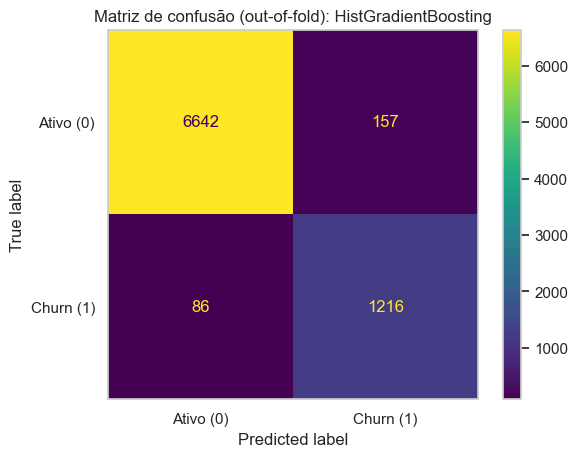

                 Previsto: Ativo (0)  Previsto: Churn (1)
Real: Ativo (0)                 6642                  157
Real: Churn (1)                   86                 1216


In [11]:
# Treinamento e avaliação inicial com validação cruzada estratificada, somente no TREINO.

# Diferença em relação ao template, que já avalia no teste nesta etapa: aqui o teste fica reservado para a Seção 10 (avaliação final em dados não vistos). Avaliar no teste agora tornaria aquela avaliação otimista (vazamento de informação), então usamos validação cruzada de 5 folds sobre o treino para uma estimativa honesta de desempenho em dados novos.

# Validação cruzada estratificada e reprodutível: mantém a proporção de churn em cada fold e usa a mesma semente do restante do notebook.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Baseline e candidatos avaliados do mesmo jeito, no mesmo laço.
modelos = {"Baseline": baseline, **modelos_candidatos}

series_validacao = []     # métricas out-of-fold: estimam o desempenho em dados novos.
series_treino = []        # métricas no próprio treino: revelam o quanto o modelo decora os dados.
previsoes_validacao = {}  # previsões out-of-fold por modelo, reaproveitadas na matriz de confusão.
tempos_treino = {}        # tempo para treinar cada modelo no treino completo.

for nome, modelo in modelos.items():
    # Previsões out-of-fold: cada cliente é previsto por um modelo que não o usou no fit, então estas métricas não tocam o conjunto de teste e estimam desempenho fora da amostra.
    probabilidade_validacao = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    previsao_validacao = (probabilidade_validacao >= 0.5).astype(int)
    previsoes_validacao[nome] = previsao_validacao
    series_validacao.append(avaliar_classificacao(nome, y_train, previsao_validacao, probabilidade_validacao))

    # Resubstituição: treina no treino completo e prevê o próprio treino. Comparar o F1 daqui com o F1 out-of-fold revela o gap treino x validação, principal sinal de overfitting.
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tempos_treino[nome] = time.time() - inicio
    probabilidade_treino = modelo.predict_proba(X_train)[:, 1]
    previsao_treino = (probabilidade_treino >= 0.5).astype(int)
    series_treino.append(avaliar_classificacao(nome, y_train, previsao_treino, probabilidade_treino))

# Tabela principal: desempenho out-of-fold, ordenado por F1 (foco na classe de churn).
# Acrescenta o tempo de treino, que a Seção 7.1 prometeu medir aqui.
resultados_validacao = tabela_resultados(series_validacao)
resultados_validacao["tempo_treino_segundos"] = pd.Series(tempos_treino)
print("Desempenho em validação cruzada (out-of-fold), ordenado por F1:")
display(resultados_validacao.round(4))

# Comparação treino x validação no F1, para discutir overfitting/underfitting na Seção 8.1.
gap_overfitting = pd.DataFrame({
    "f1_treino": tabela_resultados(series_treino)["f1"],
    "f1_validacao": resultados_validacao["f1"],
}).reindex(resultados_validacao.index)
gap_overfitting["gap"] = gap_overfitting["f1_treino"] - gap_overfitting["f1_validacao"]
print("\nF1 no treino x validação (gap alto sugere overfitting):")
display(gap_overfitting.round(4))

# Melhor candidato pelo F1 out-of-fold (desconsidera o Baseline); orienta a escolha da Seção 9.
melhor_candidato = resultados_validacao.drop(index="Baseline").index[0]
print(f"\nMelhor candidato por F1 (out-of-fold): {melhor_candidato}.")

# Matriz de confusão do melhor candidato, com as previsões out-of-fold (dados que ele não viu no fit). Os valores aparecem em cada célula, atendendo à regra de gráficos do projeto.
plotar_matriz_confusao(
    y_train, previsoes_validacao[melhor_candidato],
    titulo=f"Matriz de confusão (out-of-fold): {melhor_candidato}",
)

## 8.1 Análise dos resultados iniciais

Todos os números abaixo vêm das duas tabelas da célula anterior. As métricas são out-of-fold (validação cruzada de 5 folds só no treino), então estimam o desempenho em dados novos sem tocar no conjunto de teste, que fica reservado para a Seção 10.

**Os candidatos superaram o baseline?**
Sim, com folga. O baseline (prever sempre "cliente ativo") tem `F1 = 0` e `recall = 0` na classe de churn: apesar da acurácia de `83,93%`, ele não identifica nenhum cancelamento, exatamente o problema que a Seção 7.1 antecipou. Todos os cinco candidatos superam isso. Até o pior deles em `F1`, a `LogisticRegression` (`0,6423`), já encontra a maioria dos churns (`recall = 0,8518`).

**Comparação entre os candidatos.**
Os dois modelos de boosting lideram e quase empatam: `HistGradientBoosting` (`F1 = 0,9092`, `recall = 0,9339`, `ROC-AUC = 0,9933`) e `XGBoost` (`F1 = 0,9081`, `recall = 0,9255`, `ROC-AUC = 0,9926`). O `RandomForest` vem em seguida (`F1 = 0,8328`), mas com um perfil diferente: é o mais preciso (`precision = 0,9274`) e, ao mesmo tempo, o que mais deixa churn passar (`recall = 0,7558`). `KNN` (`F1 = 0,6709`) e `LogisticRegression` (`F1 = 0,6423`) ficam atrás. O `KNN` foi penalizado por não ter reponderação de classes (Seção 7.1), e a `LogisticRegression`, mesmo com `class_weight="balanced"`, tem `precision` baixa (`0,5156`): acha muitos churns, mas com muito alarme falso.

**A acurácia seria suficiente?**
Não, e isso fica explícito aqui. O baseline tem acurácia de `83,93%` sem prever um único churn. A `LogisticRegression` tem acurácia menor (`0,8475`) e, ainda assim, é muito mais útil, porque encontra cerca de `85%` dos cancelamentos. Por isso o projeto prioriza `F1` e `recall` da classe de churn (Seções 1.4 e 4.1): são essas métricas que medem o que de fato interessa.

**Há indício de underfitting ou overfitting?**
A segunda tabela compara o `F1` no próprio treino com o `F1` out-of-fold (`gap` = treino menos validação):
- `RandomForest` e `XGBoost` chegam a `F1 = 1,0000` no treino. O `RandomForest` tem o maior gap (`0,1672`), sinal claro de que decora o treino e generaliza menos; o `XGBoost` decora igual, mas generaliza muito melhor (gap `0,0919`).
- `HistGradientBoosting` tem o melhor equilíbrio entre os modelos fortes: alto desempenho out-of-fold com o menor gap dentre os de boosting (`0,0825`).
- A `LogisticRegression` quase não tem gap (`0,0058`), mas com `F1` baixo nos dois lados (`~0,64`): é o retrato de underfitting, um modelo linear simples demais para um problema com efeitos não lineares (Seção 4.1).
- Nenhum candidato mostra overfitting grave a ponto de invalidar a escolha; os gaps existem, mas o desempenho out-of-fold dos modelos de boosting continua alto.

**O tempo de treino é aceitável?**
Sim. Pela coluna `tempo_treino_segundos`, treinar cada modelo no treino completo leva no máximo cerca de um segundo, sendo o `RandomForest` o mais lento e o `KNN` e a `LogisticRegression` os mais rápidos. Para uma base de `~8.100` registros, o custo é irrelevante e não pesa na escolha. Os valores exatos em segundos variam um pouco a cada execução, conforme a máquina.

**O resultado faz sentido frente à EDA?**
Faz. A Seção 4.1 mostrou sinais não lineares fortes (a taxa de churn por inatividade salta de `4,48%` para `29,89%`), e foram justamente os modelos de árvore e boosting que melhor capturaram esse padrão, como a Seção 7.1 antecipou. A `LogisticRegression`, linear, ficou para trás.

**Conclusão e gancho para a Seção 9.**
O `HistGradientBoosting` foi o melhor candidato por `F1` out-of-fold (`0,9092`), seguido de perto pelo `XGBoost`. A matriz de confusão out-of-fold confirma o bom `recall`: a grande maioria dos churns é identificada. É esse o modelo levado para a otimização de hiperparâmetros na Seção 9.

# 9. Validação e otimização de hiperparâmetros

In [12]:
# Otimização de hiperparâmetros do HistGradientBoosting, melhor candidato por F1 out-of-fold (Seção 8.1).
# A busca usa apenas o TREINO (validação cruzada estratificada); o conjunto de teste continua reservado para a Seção 10.

# Número de combinações sorteadas. Mantido modesto para um custo baixo: com 5 folds, são 30 x 5 = 150 ajustes.
N_ITER_BUSCA = 30

# Modelo a tunar: o mesmo pipeline da Seção 7 (pré-processador + HistGradientBoosting),
# preservando class_weight='balanced' para o desbalanceamento e a semente do notebook.
modelo_para_tunar = Pipeline(steps=[
    ("preprocess", preprocessador),
    ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)),
])

# Espaço de busca. Cada hiperparâmetro controla um aspecto do boosting de árvores:
#   learning_rate     : tamanho do passo de cada árvore (passos menores aprendem mais devagar e generalizam mais).
#   max_iter          : número de árvores (iterações de boosting).
#   max_leaf_nodes    : complexidade de cada árvore (mais folhas capturam padrões mais finos, com risco de overfitting).
#   min_samples_leaf  : mínimo de amostras por folha (valores maiores regularizam, evitando folhas muito específicas).
#   l2_regularization : penalização L2 que freia o ajuste excessivo aos dados de treino.
espaco_busca = {
    "model__learning_rate": uniform(0.01, 0.29),     # intervalo [0.01, 0.30]
    "model__max_iter": randint(100, 400),
    "model__max_leaf_nodes": randint(15, 63),
    "model__min_samples_leaf": randint(10, 60),
    "model__l2_regularization": uniform(0.0, 2.0),   # intervalo [0.0, 2.0]
}

# RandomizedSearchCV: sorteia N_ITER_BUSCA combinações e avalia cada uma por validação cruzada.
#   cv=cv          : reaproveita o StratifiedKFold de 5 folds definido na Seção 8 (mesma semente).
#   scoring='f1'   : F1 da classe positiva (churn = 1), a métrica que o projeto prioriza (Seções 1.4 e 4.1).
#   n_jobs=-1      : paraleliza a busca; como tudo usa SEED, o resultado é o mesmo, só mais rápido.
busca = RandomizedSearchCV(
    modelo_para_tunar,
    param_distributions=espaco_busca,
    n_iter=N_ITER_BUSCA,
    cv=cv,
    scoring="f1",
    random_state=SEED,
    n_jobs=-1,
)
busca.fit(X_train, y_train)

# Melhor configuração encontrada e o F1 médio dela na validação cruzada.
desvio_f1_folds = busca.cv_results_["std_test_score"][busca.best_index_]
print(f"Melhor F1 (média dos folds): {busca.best_score_:.4f} (desvio entre folds: {desvio_f1_folds:.4f})")
print("Melhores hiperparâmetros:")
for parametro, valor in busca.best_params_.items():
    print(f"  {parametro}: {valor}")

# Modelo otimizado, já reajustado no treino completo; será reaproveitado na avaliação final (Seção 10).
modelo_otimizado = busca.best_estimator_

# Comparação antes x depois, na mesma metodologia out-of-fold da Seção 8, para um cotejo justo.
# Previsões out-of-fold do modelo otimizado: cada cliente é previsto por um modelo que não o usou no fit.
probabilidade_validacao_otimizado = cross_val_predict(
    modelo_otimizado, X_train, y_train, cv=cv, method="predict_proba"
)[:, 1]
previsao_validacao_otimizado = (probabilidade_validacao_otimizado >= 0.5).astype(int)

# Linha "padrão": reaproveita as métricas do HistGradientBoosting já calculadas na Seção 8
# (apenas as colunas de métrica, sem o tempo de treino, que não se aplica aqui).
colunas_metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]
linha_padrao = resultados_validacao.loc["HistGradientBoosting", colunas_metricas]
linha_padrao.name = "HistGradientBoosting (padrão)"

# Linha "otimizado": mesmas métricas, calculadas com a função auxiliar da Seção 2.2.
linha_otimizado = avaliar_classificacao(
    "HistGradientBoosting (otimizado)",
    y_train, previsao_validacao_otimizado, probabilidade_validacao_otimizado,
)[colunas_metricas]

comparacao_otimizacao = pd.DataFrame([linha_padrao, linha_otimizado])
ganho_f1 = comparacao_otimizacao.loc["HistGradientBoosting (otimizado)", "f1"] - \
    comparacao_otimizacao.loc["HistGradientBoosting (padrão)", "f1"]

print("\nComparação out-of-fold (antes x depois da otimização):")
print(comparacao_otimizacao.round(4))
print(f"\nGanho de F1 com a otimização: {ganho_f1:+.4f} (ante um desvio entre folds de {desvio_f1_folds:.4f}).")

Melhor F1 (média dos folds): 0.9199 (desvio entre folds: 0.0101)
Melhores hiperparâmetros:
  model__l2_regularization: 1.0397633727625066
  model__learning_rate: 0.2617500287365414
  model__max_iter: 326
  model__max_leaf_nodes: 27
  model__min_samples_leaf: 16



Comparação out-of-fold (antes x depois da otimização):
                                  accuracy  precision  recall      f1  roc_auc
HistGradientBoosting (padrão)       0.9700     0.8857  0.9339  0.9092   0.9933
HistGradientBoosting (otimizado)    0.9741     0.9136  0.9263  0.9199   0.9932

Ganho de F1 com a otimização: +0.0107 (ante um desvio entre folds de 0.0101).


## 9.1 Discussão da otimização

**Qual modelo foi otimizado e por quê.**
O modelo levado para a otimização foi o `HistGradientBoosting`, escolhido por ter sido o melhor candidato na avaliação inicial (Seção 8.1), com `F1 = 0,9092` out-of-fold, à frente do `XGBoost`. Otimizar o candidato mais forte é a aposta com maior chance de melhorar o resultado final.

**Quais hiperparâmetros foram testados e o papel de cada um.**
A busca variou cinco hiperparâmetros do boosting de árvores:
- `learning_rate`: o tamanho do passo de cada árvore. Passos menores aprendem mais devagar e tendem a generalizar melhor.
- `max_iter`: o número de árvores (iterações de boosting).
- `max_leaf_nodes`: a complexidade de cada árvore. Mais folhas capturam padrões mais finos, com maior risco de overfitting.
- `min_samples_leaf`: o mínimo de amostras por folha. Valores maiores regularizam, evitando folhas muito específicas.
- `l2_regularization`: uma penalização que freia o ajuste excessivo aos dados de treino.

**Qual estratégia de validação e qual métrica guiaram a escolha.**
Usamos `RandomizedSearchCV` com `30` combinações sorteadas, avaliadas pela mesma validação cruzada estratificada de 5 folds da Seção 8 (`StratifiedKFold`), sempre apenas sobre o treino. O conjunto de teste continua reservado para a Seção 10, o que evita vazamento. A métrica que guiou a busca foi o `F1` da classe de churn (`pos_label = 1`), coerente com o critério de sucesso do projeto (Seções 1.4 e 4.1): em um problema desbalanceado, é essa métrica que mede o que interessa, e não a acurácia.

**Qual foi a melhor configuração encontrada.**
A melhor combinação teve `learning_rate ~ 0,262`, `max_iter = 326`, `max_leaf_nodes = 27`, `min_samples_leaf = 16` e `l2_regularization ~ 1,04`, com `F1` médio de `0,9199` nos folds. Os valores fazem sentido: a busca preferiu uma taxa de aprendizado na metade superior do intervalo testado (`learning_rate ~ 0,262`), compensada por árvores de complexidade contida (`max_leaf_nodes = 27`, bem abaixo do limite da busca) e por uma regularização L2 razoável (`l2_regularization ~ 1,04`). É um equilíbrio coerente com o gap de overfitting já observado nos modelos de árvore na Seção 8.1: passos maiores aprendem mais rápido, mas a poda das árvores e a penalização L2 seguram o ajuste excessivo ao treino.

**A otimização melhorou o resultado em relação ao modelo inicial?**
Pouco. Na comparação out-of-fold (mesma metodologia da Seção 8), o `F1` subiu de `0,9092` para `0,9199`, um ganho de `+0,0107`. Esse ganho é da mesma ordem do desvio do `F1` entre os folds (`0,0101`), ou seja, é pequeno e está dentro da faixa de variação esperada da validação cruzada. A melhora veio sobretudo da `precision` (de `0,8857` para `0,9136`), enquanto o `recall`, que é a métrica prioritária do projeto, teve uma queda pequena (de `0,9339` para `0,9263`). O `ROC-AUC` praticamente não mudou (`0,9933` para `0,9932`). Na prática, o `HistGradientBoosting` com hiperparâmetros padrão já seria uma escolha defensável. Seguimos com a versão otimizada porque a queda de `recall` é mínima e, em troca, a `precision` sobe de forma mais visível, gerando menos alarme falso para um poder de detecção quase igual.

**A busca foi limitada por tempo, custo ou tamanho da base?**
A base de treino é pequena (`~8.100` registros) e o `HistGradientBoosting` é rápido, então a busca de `30` combinações rodou em poucos minutos. A limitação real não foi de custo, e sim o teto de desempenho: o modelo padrão já estava muito bom (`F1 ~ 0,91`), deixando pouca margem para ganho. Com mais tempo, valeria testar um espaço de busca maior ou um `GridSearchCV` mais fino em torno dos valores encontrados, além de revisar o limiar de decisão (hoje fixo em `0,5`) para equilibrar `precision` e `recall` conforme o custo de negócio, algo que costuma render mais que o ajuste de hiperparâmetros quando o modelo já está saturado.

# 10. Avaliação final no conjunto de teste

Desempenho no conjunto de teste (dados não vistos), ordenado por F1:


,accuracy,precision,recall,f1,roc_auc
HistGradientBoosting otimizado (teste),0.9704,0.9233,0.8892,0.906,0.9932
Baseline (teste),0.8396,0.0000,0.0000,0.000,0.5000



F1 do modelo final | validação cruzada (Seção 9): 0.9199 | teste: 0.9060
Diferença (teste menos validação): -0.0140.

Relatório de classificação no teste (classe 1 = churn):
              precision    recall  f1-score   support

   Ativo (0)       0.98      0.99      0.98      1701
   Churn (1)       0.92      0.89      0.91       325

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



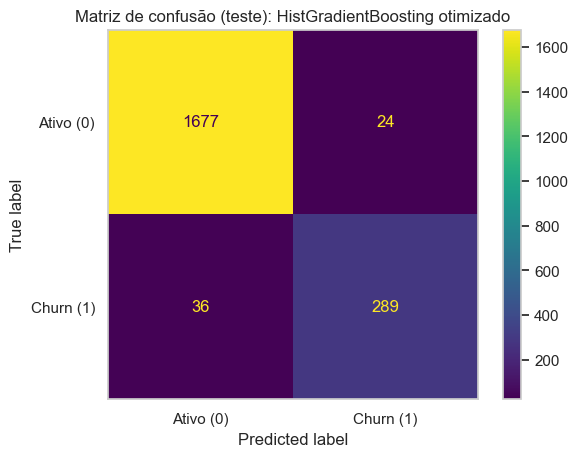

                 Previsto: Ativo (0)  Previsto: Churn (1)
Real: Ativo (0)                 1677                   24
Real: Churn (1)                   36                  289


In [13]:
# Avaliação final no conjunto de TESTE: dados que nenhum modelo viu durante o treino
# nem durante a escolha de hiperparâmetros (Seção 9). Esta é a estimativa honesta de
# desempenho em dados novos, feita uma única vez para não contaminar o teste.

# Modelo final: o HistGradientBoosting otimizado da Seção 9, já reajustado no treino
# completo (best_estimator_). O baseline da Seção 7 entra como referência mínima.
modelo_final = modelo_otimizado

# Previsões no teste: probabilidade da classe de churn e classe prevista com limiar de
# 0.5, o mesmo limiar usado no restante do notebook.
probabilidade_teste_final = modelo_final.predict_proba(X_test)[:, 1]
previsao_teste_final = (probabilidade_teste_final >= 0.5).astype(int)

probabilidade_teste_baseline = baseline.predict_proba(X_test)[:, 1]
previsao_teste_baseline = (probabilidade_teste_baseline >= 0.5).astype(int)

# Tabela final no teste: baseline vs modelo otimizado, ordenada por F1 (classe de churn),
# reaproveitando as funções auxiliares da Seção 2.2.
resultados_teste = tabela_resultados([
    avaliar_classificacao(
        "Baseline (teste)", y_test, previsao_teste_baseline, probabilidade_teste_baseline
    ),
    avaliar_classificacao(
        "HistGradientBoosting otimizado (teste)", y_test, previsao_teste_final, probabilidade_teste_final
    ),
])
print("Desempenho no conjunto de teste (dados não vistos), ordenado por F1:")
display(resultados_teste.round(4))

# Validação cruzada (Seção 9) x teste: se o F1 no teste fica próximo do F1 out-of-fold,
# o desempenho se sustenta em dados novos, sem overfitting à seleção de hiperparâmetros.
f1_validacao_final = busca.best_score_
f1_teste_final = resultados_teste.loc["HistGradientBoosting otimizado (teste)", "f1"]
print(f"\nF1 do modelo final | validação cruzada (Seção 9): {f1_validacao_final:.4f} | teste: {f1_teste_final:.4f}")
print(f"Diferença (teste menos validação): {f1_teste_final - f1_validacao_final:+.4f}.")

# Relatório de classificação completo no teste: precision, recall e F1 por classe.
print("\nRelatório de classificação no teste (classe 1 = churn):")
print(classification_report(y_test, previsao_teste_final, target_names=["Ativo (0)", "Churn (1)"]))

# Matriz de confusão no teste, com as contagens em cada célula do gráfico e em texto
# (função da Seção 2.2), atendendo à regra de gráficos do projeto.
plotar_matriz_confusao(
    y_test, previsao_teste_final,
    titulo="Matriz de confusão (teste): HistGradientBoosting otimizado",
)


## 10.1 Análise de erros e limitações

**Os resultados fazem sentido?**
Sim. No conjunto de teste (dados que nenhum modelo viu), o `HistGradientBoosting` otimizado alcançou `F1 = 0,9060`, `recall = 0,8892`, `precision = 0,9233` e `ROC-AUC = 0,9932` na classe de churn, contra um baseline que prevê sempre "cliente ativo" e fica com `F1 = 0` (não identifica nenhum cancelamento). O resultado no teste é próximo da estimativa out-of-fold da Seção 9 (`F1 = 0,9199`), com diferença de apenas `-0,0140`. Essa proximidade é o ponto central: o desempenho se sustenta em dados novos, sinal de que não houve overfitting ao treino nem à seleção de hiperparâmetros.

**Análise de erros (matriz de confusão no teste).**
Dos `325` clientes que realmente cancelaram, o modelo identificou `289` e deixou passar `36` (falsos negativos). Dos `1.701` clientes ativos, classificou `24` como churn (falsos positivos). Os dois tipos de erro têm pesos diferentes no negócio: o falso negativo (um cliente que vai cancelar e não é sinalizado) é o mais custoso, porque elimina a chance de uma ação de retenção; o falso positivo apenas direciona um contato de retenção a quem não iria sair. O modelo erra um pouco mais no tipo custoso (`36` contra `24`), mas o `recall` de `0,8892` mostra que ainda captura quase `89%` dos cancelamentos, e a `precision` de `0,9233` indica que cerca de `92%` dos clientes sinalizados como churn de fato cancelam.

**Há sinais de overfitting ou underfitting?**
Não de forma preocupante. A Seção 8.1 já mostrava o gap treino x validação dos modelos de árvore; aqui, o `F1` no teste (`0,9060`) ficar tão próximo do `F1` de validação cruzada (`0,9199`) confirma que o modelo generaliza. Não há underfitting (o desempenho é alto) nem overfitting relevante (a perda da validação para o teste é pequena).

**A métrica escolhida captura bem o objetivo?**
Sim. O projeto prioriza `F1` e `recall` da classe de churn (Seções 1.4 e 4.1), porque o objetivo é identificar quem tende a cancelar para agir antes. A acurácia sozinha enganaria: o baseline tem `acurácia = 83,96%` no teste sem detectar um único churn. `F1` e `recall` medem justamente o que interessa em uma base desbalanceada.

**Quais as principais limitações da solução?**
- Os dados são um retrato estático e histórico de um único banco, sem dimensão temporal: o modelo estima se um cliente tende ao churn, mas não quando isso ocorrerá.
- O limiar de decisão está fixo em `0,5`. Ajustá-lo permitiria trocar `precision` por `recall` conforme o custo de reter um cliente frente ao de perdê-lo, algo que pode render mais do que novos ajustes de hiperparâmetros.
- Várias features descrevem comportamento passado (transações, limites, inatividade); se o perfil da carteira mudar, o modelo precisa ser reavaliado.
- A base é relativamente pequena (`~10.000` clientes) e vem de uma fonte pública não versionada, então a generalização para outros bancos ou produtos não está garantida.

**Em quais cenários o modelo não deveria ser usado?**
Em outra instituição ou produto sem uma nova validação; em decisões automáticas sem revisão humana, dado que ainda restam `36` falsos negativos e `24` falsos positivos no teste; e como previsão do prazo de cancelamento, para a qual ele não foi treinado.

# 11. Comparação final dos modelos

In [14]:
# TODO: tabela final comparando baseline vs candidatos vs modelo tunado
# TODO: discutir overfitting/underfitting (treino vs teste)

# 12. Boas práticas e rastreabilidade
_(Confirme: seeds fixas, bibliotecas informadas, tempo de treino/recursos quando relevante,
código organizado e sem repetição desnecessária.)_

# 13. Conclusão
_(Resuma: problema, dataset, principais tratamentos, modelos avaliados, melhor resultado e por
que foi escolhido, se o objetivo foi cumprido, limitações e próximos passos.)_

# 14. Salvamento de artefatos

In [15]:
# TODO: (opcional) salvar o pipeline/modelo final em models/ (ex.: joblib.dump)

# 15. Apêndice opcional: métodos avançados
_(Opcional: Deep Learning, ensembles ou outras técnicas, apenas se fizerem sentido e forem
explicadas.)_